In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [7]:
df = pd.read_csv("customer_shopping_data.csv")

In [8]:
df.shape

(99457, 10)

In [10]:
df.columns

Index(['invoice_no', 'customer_id', 'gender', 'age', 'category', 'quantity',
       'price', 'payment_method', 'invoice_date', 'shopping_mall'],
      dtype='str')

In [12]:
df["invoice_date"].isnull().sum()

np.int64(0)

In [14]:
df["invoice_date"] = pd.to_datetime(df["invoice_date"], format="%Y-%m-%d", errors="coerce")

In [15]:
df["year"] = df["invoice_date"].dt.year
df["month"] = df["invoice_date"].dt.month

In [17]:
mall_sales = df.groupby("shopping_mall")["price"].sum().sort_values(ascending=False)
mall_sales #avm uzre

shopping_mall
Mall of Istanbul     13851737.62
Kanyon               13710755.24
Metrocity            10249980.07
Metropol AVM          6937992.99
Istinye Park          6717077.54
Zorlu Center          3509649.02
Cevahir AVM           3433671.84
Viaport Outlet        3414019.46
Emaar Square Mall     3390408.31
Forum Istanbul        3336073.82
Name: price, dtype: float64

In [18]:
category_sales = df.groupby("category")["price"].sum().sort_values(ascending=False)
category_sales

category
Clothing           31075684.64
Shoes              18135336.89
Technology         15772050.00
Cosmetics           1848606.90
Toys                1086704.64
Food & Beverage      231568.71
Books                226977.30
Souvenir             174436.83
Name: price, dtype: float64

In [19]:
gender_sales = df.groupby("gender")["price"].sum()
gender_sales

gender
Female    40931801.62
Male      27619564.29
Name: price, dtype: float64

In [20]:
payment_sales = df.groupby("payment_method")["price"].sum().sort_values(ascending=False)
payment_sales

payment_method
Cash           30705030.98
Credit Card    24051476.93
Debit Card     13794858.00
Name: price, dtype: float64

In [21]:
pivot = pd.pivot_table(df,
    values="price",
    index="shopping_mall",
    columns="category",
    aggfunc="sum")
pivot

category,Books,Clothing,Cosmetics,Food & Beverage,Shoes,Souvenir,Technology,Toys
shopping_mall,,,,,,,,
Cevahir AVM,11998.80,1554414.40,88394.84,11992.39,884050.41,8304.84,819000.0,55516.16
Emaar Square Mall,11059.50,1511803.04,92379.52,11030.07,871446.84,8515.98,834750.0,49423.36
Forum Istanbul,11453.40,1572119.12,95225.72,10836.56,875648.03,9090.75,706650.0,55050.24
Istinye Park,20725.20,3050313.20,178741.36,23419.94,1806511.70,18369.18,1509900.0,109096.96
Kanyon,44980.35,6155541.04,372242.30,45474.85,3640031.05,35483.25,3202500.0,214502.40
Mall of Istanbul,46949.85,6245565.04,373787.38,46431.94,3668239.04,34263.33,3220350.0,216151.04
Metrocity,34405.65,4719958.32,272422.00,35375.72,2610139.33,25770.81,2386650.0,165258.24
Metropol AVM,22240.20,3166444.16,185775.54,23984.78,1942750.29,18603.78,1465800.0,112394.24
Viaport Outlet,10908.00,1530708.08,92664.14,11432.78,882850.07,7636.23,823200.0,54620.16


In [22]:
yearly = df.groupby(["year", "category"])["price"].sum().reset_index()

In [24]:
gender_cat = df.groupby(["gender", "category"])["price"].sum().reset_index()

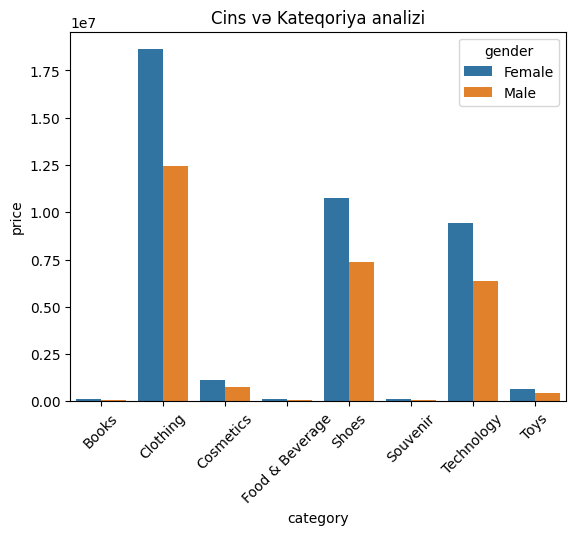

In [25]:
sns.barplot(data=gender_cat, x="category", y="price", hue="gender")
plt.xticks(rotation=45)
plt.title("Cins və Kateqoriya analizi")
plt.show()

In [ ]:
monthly_mall = df.groupby(["shopping_mall", "year", "month"])["price"].sum().reset_index()
monthly_mall.sort_values(["shopping_mall", "year", "month"], inplace=True)
monthly_mall["growth"] = monthly_mall.groupby("shopping_mall")["price"].pct_change()
monthly_mall.head() #bonus hissesi

,shopping_mall,year,month,price,growth


In [35]:
payment_category = df.groupby(["category", "payment_method"])["price"].sum().reset_index()
payment_category

,category,payment_method,price
0,Books,Cash,103489.65
1,Books,Credit Card,76689.30
2,Books,Debit Card,46798.35
3,Clothing,Cash,13966323.36
4,Clothing,Credit Card,10765970.16
5,Clothing,Debit Card,6343391.12
6,Cosmetics,Cash,810394.46
7,Cosmetics,Credit Card,662066.78
8,Cosmetics,Debit Card,376145.66
9,Food & Beverage,Cash,102628.29
